# Bike Rental Demand Prediction Using Regression Models

## Project Goal

To develop a predictive system that estimates daily bike rental demand using historical and environmental data. The objective was to experiment across regression algorithms and optimize performance using feature engineering and hyperparameter tuning.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
dataset=pd.read_csv(r"C:\Users\santh\OneDrive\Desktop\final projects datamites\PRCP-1018-BikeRental\Data\day.csv")

## Dataset Overview

⦁ Source: day.csv from Bike Sharing Dataset
⦁ Records: 731 rows × 16 columns
⦁ Target variable: cnt (total bike rentals)
⦁ Features include: seasonality, date metadata, weather conditions, temperature, windspeed, humidity

In [3]:
dataset.head(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,02-01-2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,03-01-2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,04-01-2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,05-01-2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
dataset.tail(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,27-12-2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,28-12-2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,29-12-2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,30-12-2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,31-12-2012,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [5]:
dataset.shape

(731, 16)

In [6]:
dataset.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

## Exploratory Data Analysis

### No missing values

In [7]:
dataset.isnull().sum().sum()

0

### No duplicate records

In [8]:
dataset.duplicated().sum().sum()

0

### Categorical encoding checks

In [9]:
dataset['season'].unique()

array([1, 2, 3, 4], dtype=int64)

In [10]:
dataset['weathersit'].unique()

array([2, 1, 3], dtype=int64)

In [11]:
dataset['weekday'].unique()

array([6, 0, 1, 2, 3, 4, 5], dtype=int64)

In [12]:
 dataset['holiday'].unique()

array([0, 1], dtype=int64)

In [13]:
dataset['workingday'].unique()

array([0, 1], dtype=int64)

## Visual Insights

### Season vs Count(cnt) graph

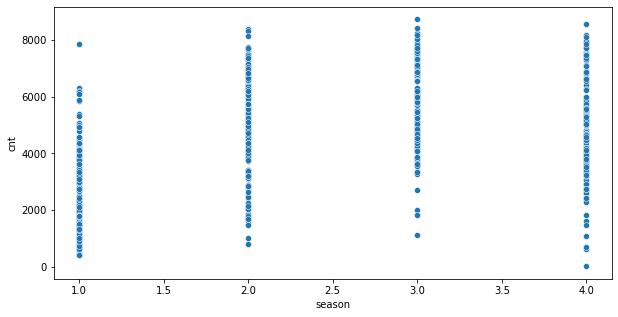

<Figure size 432x288 with 0 Axes>

In [132]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="season", y="cnt",data=dataset)
plt.show()
# plt.savefig('season_vs_count.png')

### Year(yr) vs Count(cnt) 

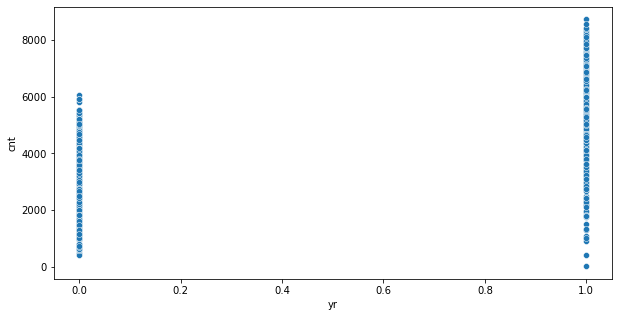

In [15]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="yr", y="cnt",data=dataset)
plt.show()

### Month(mnth) vs Count(cnt)

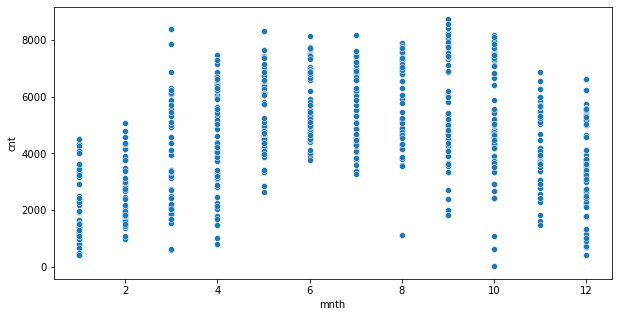

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="mnth", y="cnt",data=dataset)
plt.show()

### Holiday vs Count(cnt)

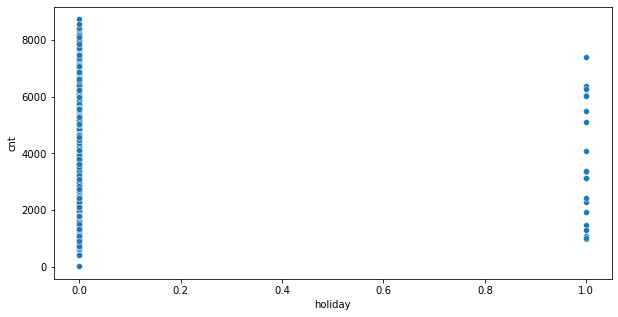

In [17]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="holiday", y="cnt",data=dataset)
plt.show()

### Weekday vs Count(cnt)

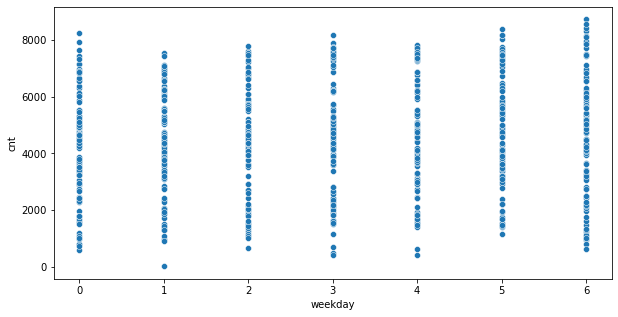

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="weekday", y="cnt",data=dataset)
plt.show()

### Workingday vs Count(cnt)

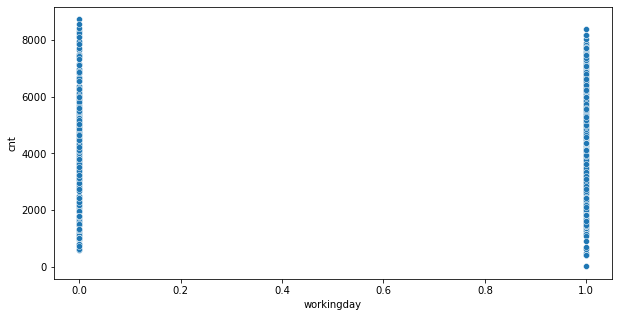

In [19]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="workingday", y="cnt",data=dataset)
plt.show()

### Weathersituation(weathersit)  vs Count(cnt)

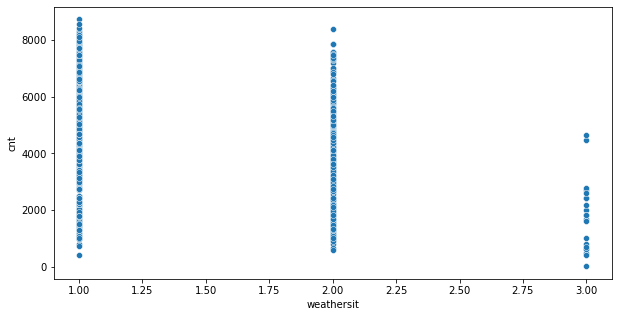

In [20]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="weathersit", y="cnt",data=dataset)
plt.show()

### Temperature(temp) vs Count(cnt)

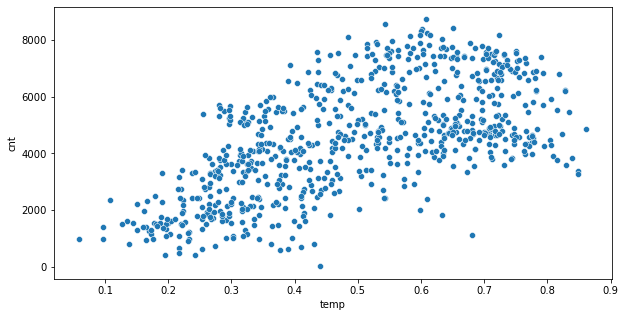

In [21]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="temp", y="cnt",data=dataset)
plt.show()

### Feelsliketeampertaure (atemp) vs count(cnt)

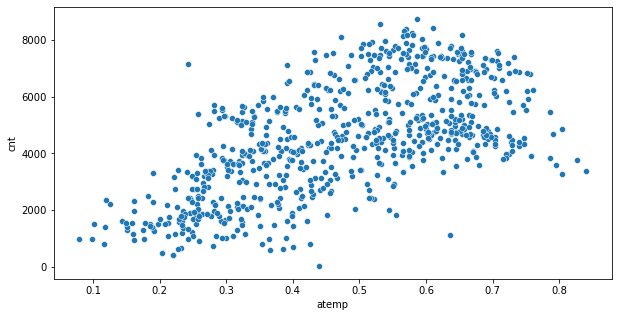

In [22]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="atemp", y="cnt",data=dataset)
plt.show()

### Humidity(hum) vs Count(cnt)

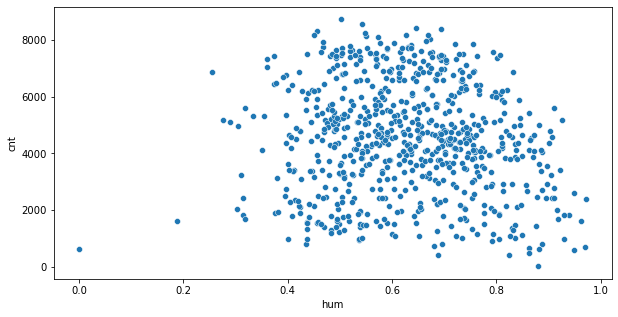

In [23]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="hum", y="cnt",data=dataset)
plt.show()

### Windspeed vs Count(cnt)

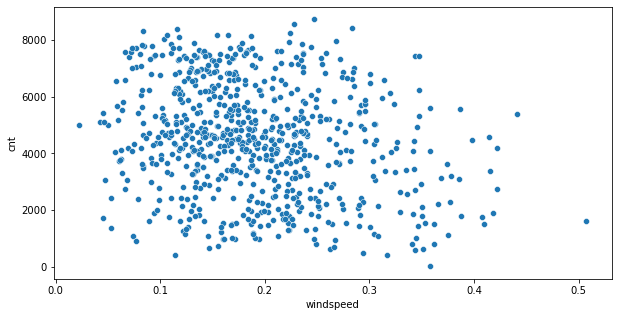

In [24]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="windspeed", y="cnt",data=dataset)
plt.show()

### Casual vs Count(cnt)

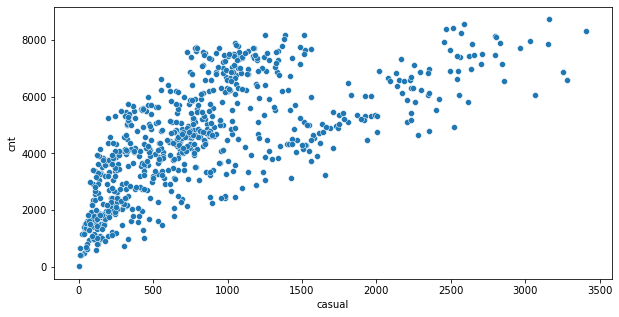

In [25]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="casual", y="cnt",data=dataset)
plt.show()

### Registered vs Count(cnt)

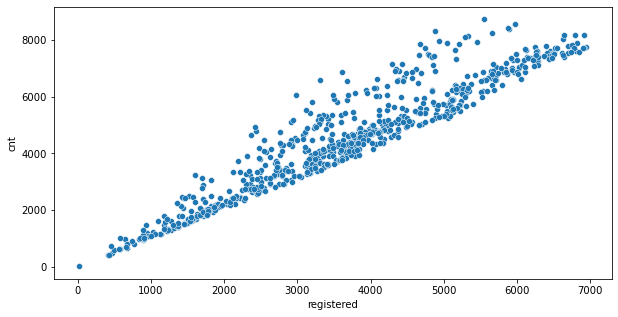

In [26]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="registered", y="cnt",data=dataset)
plt.show()

### Univariate and bivariate plots for cnt vs. season, month, weekday, workingday, weather

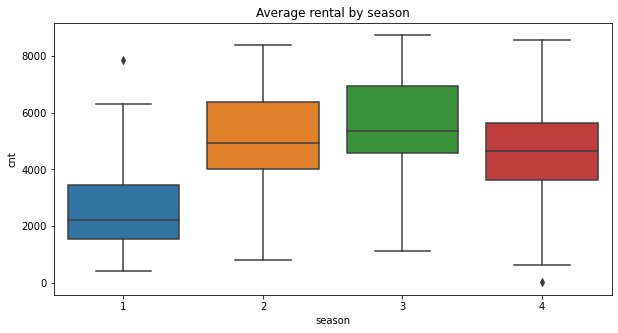

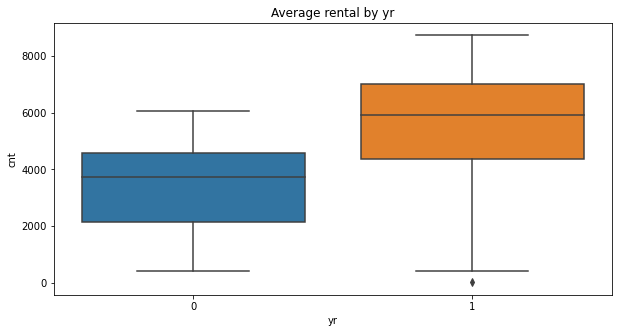

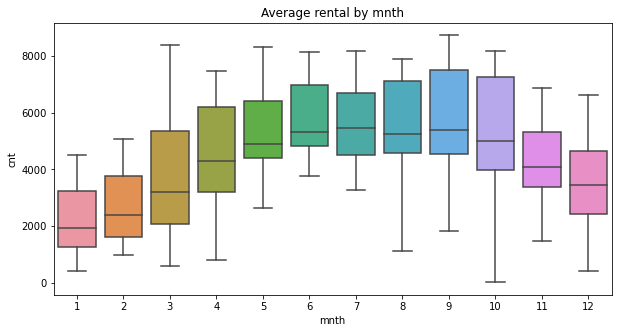

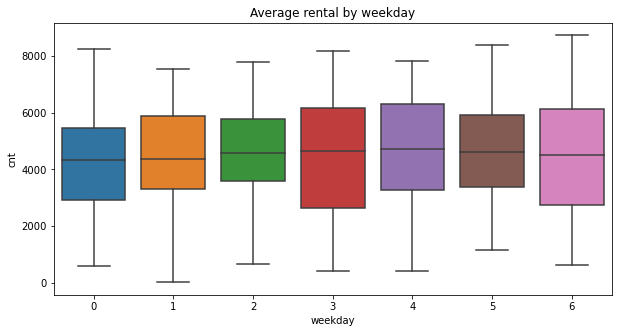

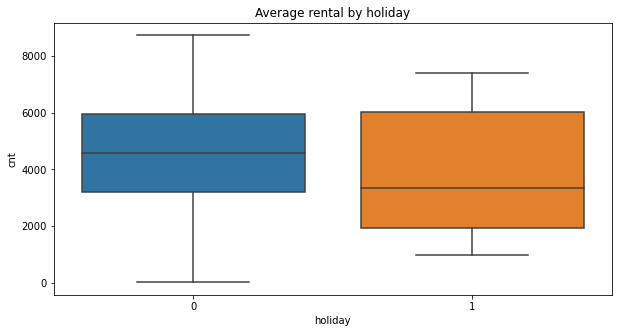

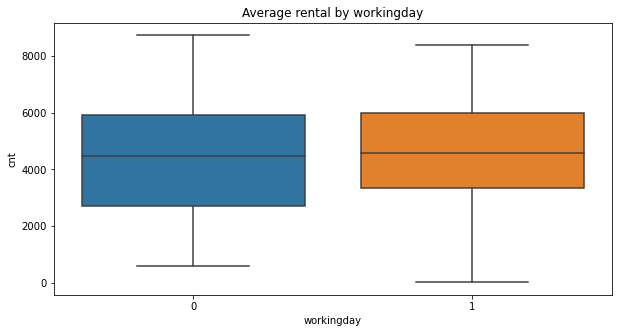

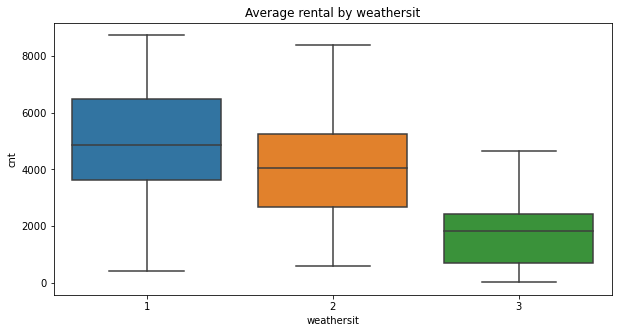

In [27]:
# Assume 'dataset' is your pandas DataFrame loaded with the data.

# List of all features you want to create a boxplot for
features_to_plot = [
    'season',
    'yr',
    'mnth',
    'weekday',
    'holiday',
    'workingday',
    'weathersit'
]

# Loop through the list of features and create a boxplot for each one
for feature in features_to_plot:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=dataset, x=feature, y='cnt')
    plt.title(f'Average rental by {feature}')
    plt.show()

## Average Rentals by Month

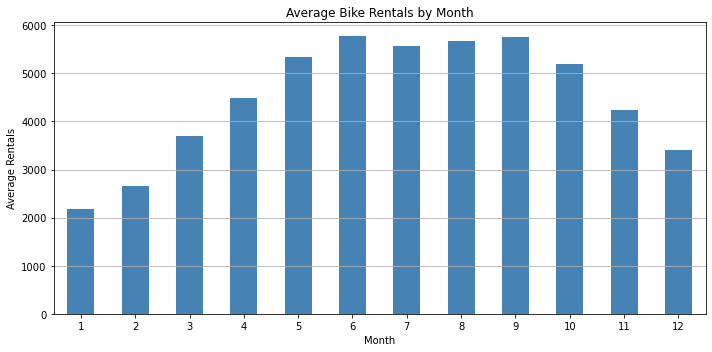

In [28]:
monthly_avg = dataset.groupby("mnth")["cnt"].mean()
plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar', color='steelblue')
plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Average Rentals by Weekday

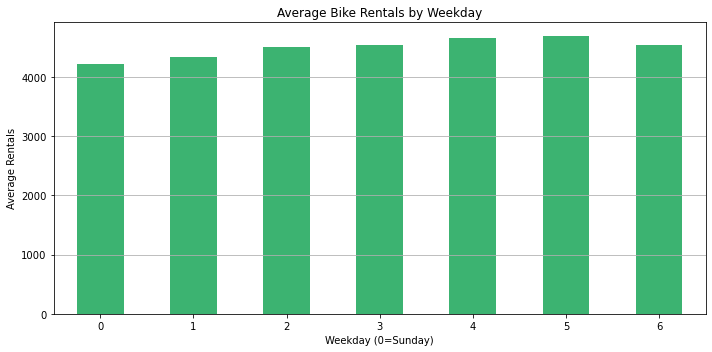

In [29]:
weekday_avg = dataset.groupby("weekday")["cnt"].mean()
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='mediumseagreen')
plt.title("Average Bike Rentals by Weekday")
plt.xlabel("Weekday (0=Sunday)")
plt.ylabel("Average Rentals")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## Histogram with KDE – Distribution of Total Rentals

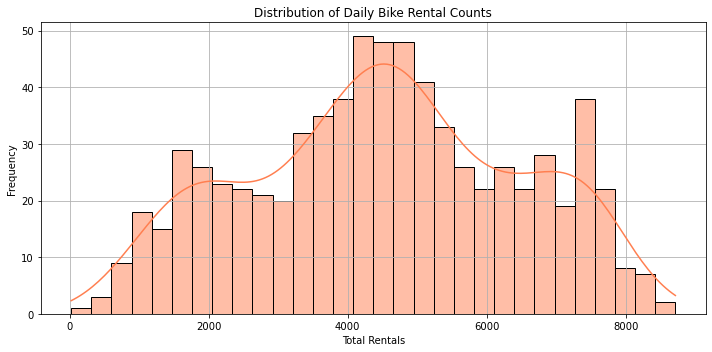

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(dataset['cnt'], bins=30, kde=True, color='coral')
plt.title("Distribution of Daily Bike Rental Counts")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


## Pie Chart – Casual vs Registered Users

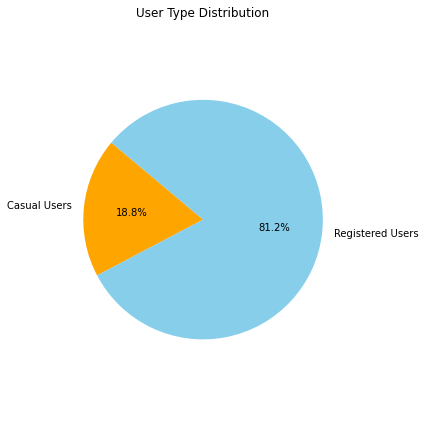

In [31]:
labels = ['Casual Users', 'Registered Users']
sizes = [dataset['casual'].sum(), dataset['registered'].sum()]
colors = ['orange', 'skyblue']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("User Type Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()


## Variance Inflation Factor

In [32]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from sklearn.preprocessing import StandardScaler

# # Drop target and leakage columns
# x = dataset.drop(columns=['cnt', 'casual', 'registered', 'dteday','instant','atemp'])  # drop date and targets

# # Optional: Print selected columns for clarity
# print("Selected columns for VIF:\n", X.columns.tolist())

# # Standardize the features
# scaler = StandardScaler()
# x_scaled = scaler.fit_transform(x)

# # Calculate VIF
# vif_data = pd.DataFrame()
# vif_data["Feature"] = x.columns
# vif_data["VIF"] = [variance_inflation_factor(x_scaled, i) for i in range(x_scaled.shape[1])]

# # Display the result
# print("\nVariance Inflation Factor (VIF):\n")
# print(vif_data.sort_values(by="VIF", ascending=False))


## Heatmap

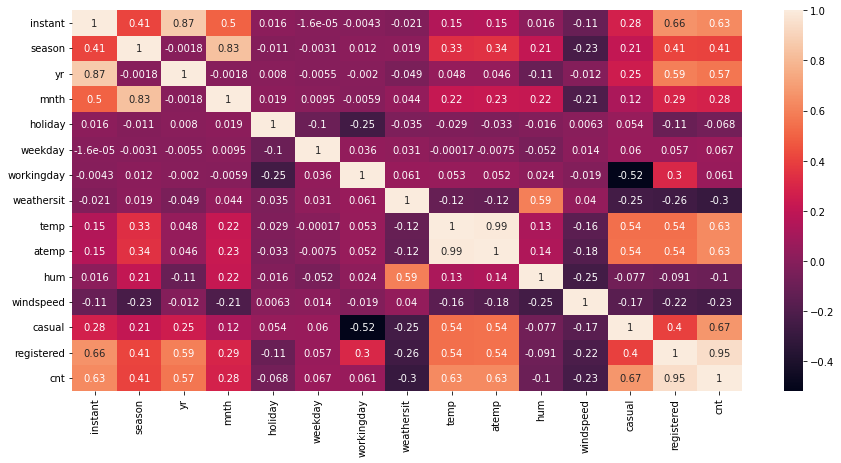

In [33]:
plt.figure(figsize=(15,7))
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

#### Correlation heatmap revealed casual and registered had strong correlations with cnt

# Modeling Workflow

## linear regression (simple linear regression)

In [34]:
# Drop columns not needed
x = dataset.drop(['instant','dteday','casual','registered','cnt'], axis=1)
y = dataset['cnt']


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [38]:
lr.score(x_test,y_test)*100,lr.score(x_train,y_train)*100

(82.76670090367213, 79.10851850465887)

### Actual VS Predicted of Linear Regression

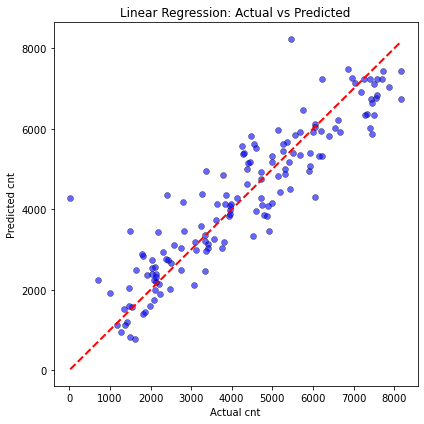

In [39]:
y_pred1 = lr.predict(x_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred1, color='blue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


### Residuals of Linear Regression

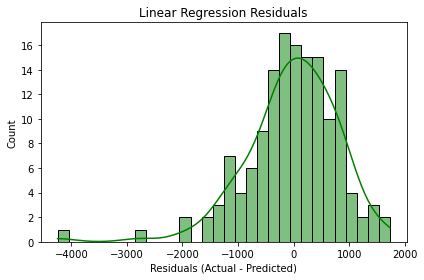

In [40]:
residuals = y_test - y_pred1

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='green')
plt.title("Linear Regression Residuals")
plt.xlabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


### Plot each feature vs cnt (Linear Regression)

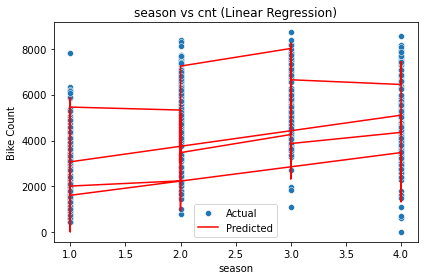

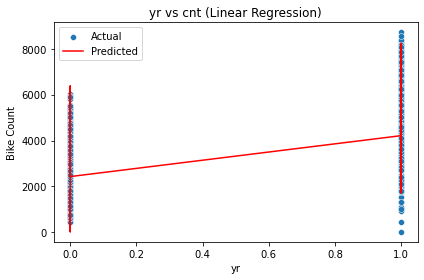

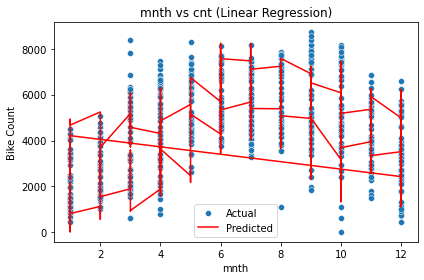

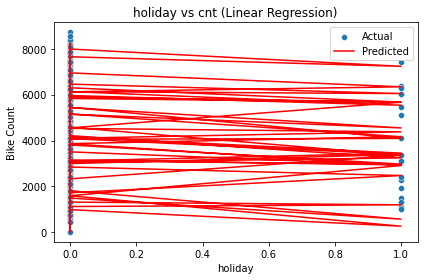

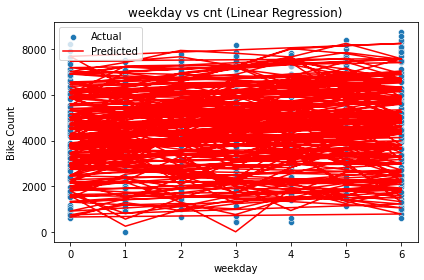

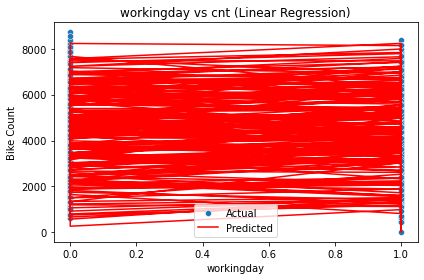

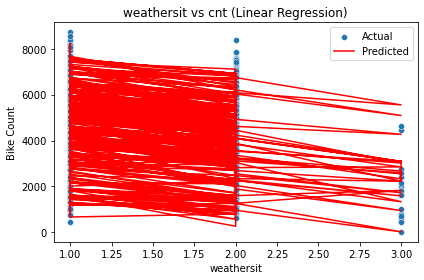

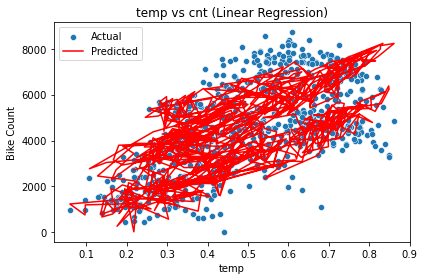

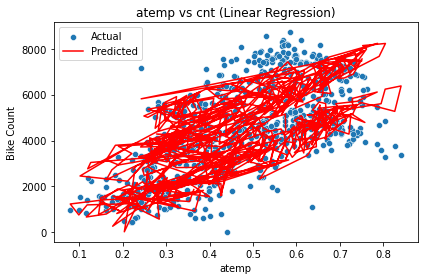

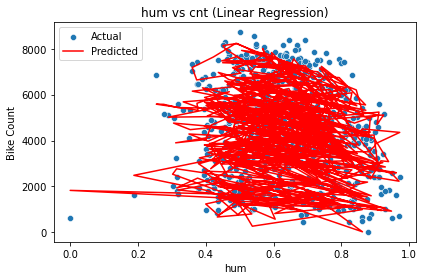

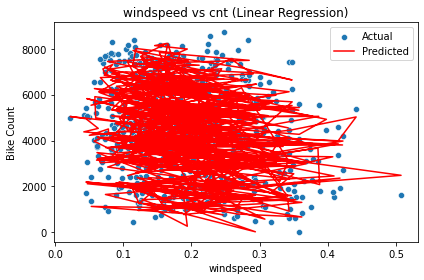

In [41]:
y_pred=lr.predict(x)
for col in x.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=dataset[col], y=dataset['cnt'], label='Actual')
    plt.plot(dataset[col], y_pred, color='red', label='Predicted')
    plt.xlabel(col)
    plt.ylabel("Bike Count")
    plt.title(f"{col} vs cnt (Linear Regression)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## DECISION TREE

In [42]:
from sklearn.tree import DecisionTreeRegressor

In [43]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [44]:
dt.score(x_train,y_train)*100,dt.score(x_test,y_test)*100

(100.0, 77.55558608805879)

### GridSearchCV for DecisionTreeRegressor

In [45]:
from sklearn.model_selection import GridSearchCV

dfg= {'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 50],
    'min_impurity_decrease': [0.0, 0.01, 0.1],
    'ccp_alpha': [0.0, 0.01, 0.1]}

# Initialize model
dt = DecisionTreeRegressor(random_state=42)

gd = GridSearchCV(estimator=dt, param_grid=dfg, cv=5, scoring='r2', n_jobs=-1, verbose=1)
gd.fit(x_train, y_train)



Fitting 5 folds for each of 38880 candidates, totalling 194400 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.01, 0.1],
                         'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'max_features': [None, 'sqrt', 'log2'],
                         'max_leaf_nodes': [None, 10, 20, 50],
                         'min_impurity_decrease': [0.0, 0.01, 0.1],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='r2', verbose=1)

In [46]:
gd.best_params_

{'ccp_alpha': 0.1,
 'criterion': 'poisson',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [47]:
dtg=DecisionTreeRegressor(
    criterion='poisson',
    splitter='random',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    ccp_alpha=0.1)
dtg.fit(x_train,y_train)
dtg.score(x_train,y_train)*100,dtg.score(x_test,y_test)*100

(90.02953753676984, 85.29189471601576)

In [48]:
gd.best_score_

0.8230419054643321

### Feature Importance Bar Plot for Decision Tree

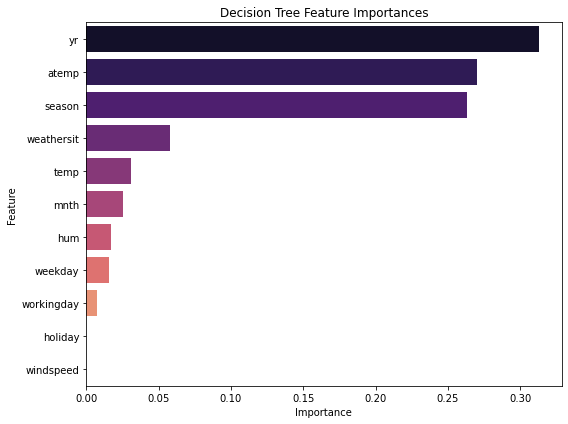

In [49]:
feat_imp = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': dtg.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()


### Actual vs Predicted Scatter Plot

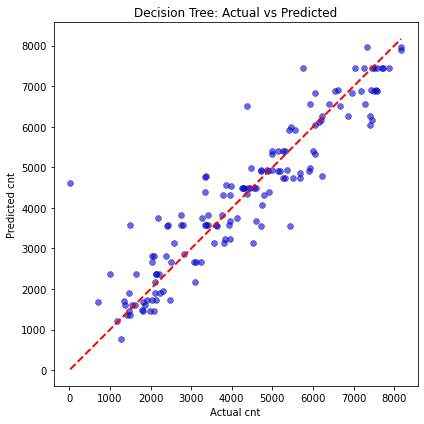

In [50]:
y_pred = dtg.predict(x_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Decision Tree: Actual vs Predicted")
plt.tight_layout()
plt.show()


### Residuals Distribution

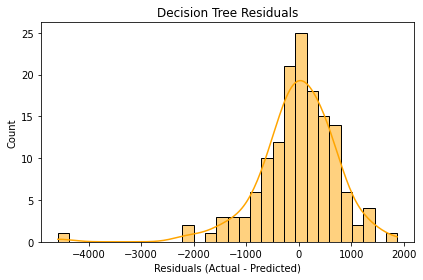

In [51]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title("Decision Tree Residuals")
plt.xlabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


### RandomizedSearchCV for DecisionTree Regressor

In [52]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'criterion': ['absolute_error', 'friedman_mse', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': list(range(2, 20)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1]
}
# Initialize model
dt = DecisionTreeRegressor(random_state=42)

# Set up RandomizedSearchCV
rs = RandomizedSearchCV(estimator=dt, param_distributions=params,
                                   n_iter=50, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit the model
rs.fit(x_train, y_train)



Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'ccp_alpha': [0.0, 0.01, 0.1],
                                        'criterion': ['absolute_error',
                                                      'friedman_mse',
                                                      'poisson'],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'splitter': ['best', 'random']},
                   scoring='r2', verbose=1)

In [53]:
rs.best_params_

{'splitter': 'random',
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': None,
 'max_depth': 7,
 'criterion': 'friedman_mse',
 'ccp_alpha': 0.1}

In [54]:
dtr=DecisionTreeRegressor(
  splitter= 'random',
 min_samples_split= 10,
 min_samples_leaf= 2,
 max_features= None,
 max_depth=17,
 criterion= 'poisson',
 ccp_alpha= 0.0)
dtr.fit(x_train,y_train)
dtr.score(x_train,y_train)*100,dtr.score(x_test,y_test)*100

(92.13350643758727, 82.32630226223104)

In [55]:
rs.best_score_

0.8011913258351202

### Feature Importance

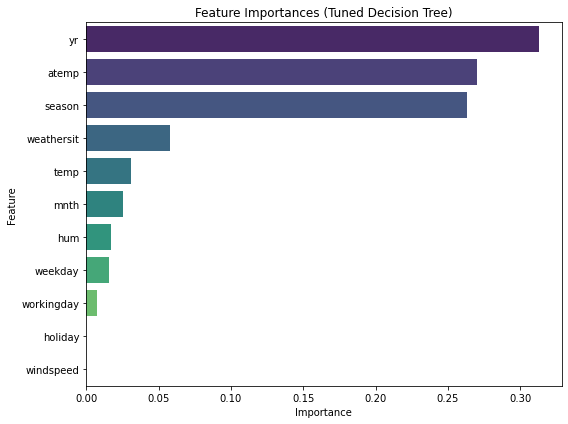

In [56]:
feat_imp = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': dtg.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title("Feature Importances (Tuned Decision Tree)")
plt.tight_layout()
plt.show()


### Actual vs Predicted Scatter Plot

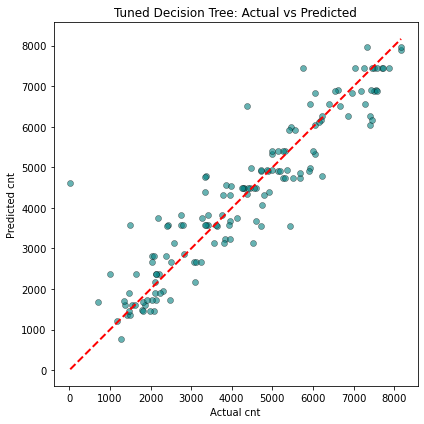

In [57]:
y_pred = dtg.predict(x_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='teal', edgecolor='k', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Tuned Decision Tree: Actual vs Predicted")
plt.tight_layout()
plt.show()


### Residuals Distribution

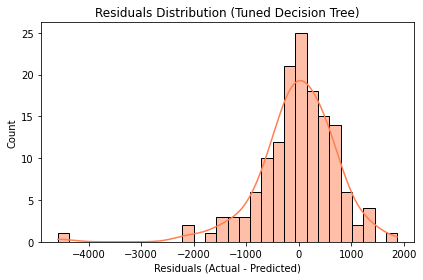

In [58]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True, color='coral')
plt.title("Residuals Distribution (Tuned Decision Tree)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


## knn

In [59]:
from sklearn.neighbors import KNeighborsRegressor

In [60]:
knn=KNeighborsRegressor(n_neighbors=4)
knn.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=4)

In [61]:
knn.score(x_train,y_train)*100,knn.score(x_test,y_test)*100

(85.89558470088609, 72.90369552220756)

### Gridsearch for knn

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    'n_neighbors': list(range(1, 31)),
     'weights':['uniform', 'distance'],
     'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'],
     'leaf_size':[20, 30, 40],
     'p':[1, 2],  # 1 = Manhattan, 2 = Euclidean
     'metric':['minkowski'],
     'n_jobs':[-1]  # Use all cores,
     }
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'leaf_size': [20, 30, 40], 'metric': ['minkowski'],
                         'n_jobs': [-1],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30],
                         'p': [1, 2], 'weights': ['uniform', 'distance']})

In [64]:
grid.best_params_

{'algorithm': 'auto',
 'leaf_size': 20,
 'metric': 'minkowski',
 'n_jobs': -1,
 'n_neighbors': 6,
 'p': 1,
 'weights': 'distance'}

In [65]:
knng=KNeighborsRegressor(
    n_neighbors=6,
    algorithm= 'auto',
    leaf_size= 20,
    metric= 'minkowski',
    n_jobs= -1,
    p= 1, 
    weights= 'distance'
)
knng.fit(x_train,y_train)

KNeighborsRegressor(leaf_size=20, n_jobs=-1, n_neighbors=6, p=1,
                    weights='distance')

In [66]:
knng.score(x_train,y_train)*100,knng.score(x_test,y_test)*100

(100.0, 78.72367044011568)

## svm

In [67]:
from sklearn.svm import SVR

In [68]:
sv=SVR()
sv.fit(x_train,y_train)

SVR()

In [69]:
sv.score(x_train,y_train)*100,sv.score(x_test,y_test)*100

(1.7331672046010826, -0.5024891349365346)

### Gridsearchcv for svr

In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
param_grid = {
    'kernel': ['rbf'],
    'C': [1.0, 10.0],
    'epsilon': [0.1, 0.5],
    'gamma': ['scale'],
    'shrinking': [True],
    'tol': [0.001]
}           # convergence tolerance


# Initialize model
svr = SVR()

# GridSearchCV setup
gd = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5,
                    scoring='r2', verbose=1, n_jobs=-1)
gd.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [1.0, 10.0], 'epsilon': [0.1, 0.5],
                         'gamma': ['scale'], 'kernel': ['rbf'],
                         'shrinking': [True], 'tol': [0.001]},
             scoring='r2', verbose=1)

In [72]:
gd.best_params_

{'C': 10.0,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'shrinking': True,
 'tol': 0.001}

In [73]:
svg = SVR(
    kernel='rbf',         # previously 'poly'
    C=10.0,
    epsilon=0.1,
    gamma='scale',
    tol=0.001,
    shrinking=True,
    cache_size=200,
    verbose=False,
    max_iter=-1
)
svg.fit(x_train, y_train)


SVR(C=10.0)

In [74]:
svg.score(x_train,y_train)*100,svg.score(x_test,y_test)*100

(12.896782921022975, 10.53050071794691)

### Randomsiedseachcv

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR

param_dist = {
    'kernel': ['poly', 'rbf'],
    'degree': [3, 5, 7],
    'gamma': ['scale', 'auto'],
    'coef0': [0.0, 0.1],
    'C': [0.1, 1.0, 10.0],
    'epsilon': [0.1, 0.5],
    'shrinking': [True],
    'tol': [0.001, 0.01]
}

svr = SVR()

rs = RandomizedSearchCV(svr, param_distributions=param_dist,
                        n_iter=10, cv=5, scoring='r2',
                        verbose=1, n_jobs=-1, random_state=42)

rs.fit(x_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
                   param_distributions={'C': [0.1, 1.0, 10.0],
                                        'coef0': [0.0, 0.1],
                                        'degree': [3, 5, 7],
                                        'epsilon': [0.1, 0.5],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['poly', 'rbf'],
                                        'shrinking': [True],
                                        'tol': [0.001, 0.01]},
                   random_state=42, scoring='r2', verbose=1)

In [76]:
rs.best_params_

{'tol': 0.001,
 'shrinking': True,
 'kernel': 'poly',
 'gamma': 'auto',
 'epsilon': 0.5,
 'degree': 5,
 'coef0': 0.1,
 'C': 1.0}

In [77]:
from sklearn.svm import SVR

svr = SVR(
    kernel='poly',         # your chosen kernel
    C=1.0,
    epsilon=0.5,
    gamma='auto',
    degree=5,
    coef0=0.1,
    tol=0.001,
    shrinking=True,
    cache_size=200,
    verbose=False,
    max_iter=-1
)

svr.fit(x_train, y_train)


SVR(coef0=0.1, degree=5, epsilon=0.5, gamma='auto', kernel='poly')

In [78]:
svr.score(x_train,y_train)*100,svr.score(x_test,y_test)*100

(65.34215837541223, 64.26118164660406)

if our data is now linearerly seaparable

# Ensemble Models

## bagging(meta-estimator)

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [81]:
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression

In [82]:
bg=BaggingRegressor(estimator=LinearRegression(),n_estimators=40)
bg.fit(x_train,y_train)
bg.score(x_train,y_train)*100,bg.score(x_test,y_test)*100

(79.08531273666087, 82.64854273501805)

### Gridsearchcv for bagging(meta-estimator)

In [83]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [False],
    'oob_score': [False],
    'estimator__fit_intercept': [True, False],  # tuning base estimator
    'estimator__positive': [True, False]
}

# Initialize BaggingRegressor with base estimator
bagging = BaggingRegressor(estimator=LinearRegression(), random_state=42)

# GridSearchCV setup
grid = GridSearchCV(estimator=bagging, param_grid=param_grid,
                    cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Fit search
grid.fit(x_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=BaggingRegressor(estimator=LinearRegression(),
                                        random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'bootstrap_features': [False],
                         'estimator__fit_intercept': [True, False],
                         'estimator__positive': [True, False],
                         'max_features': [0.5, 0.75, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [10, 50, 100], 'oob_score': [False]},
             scoring='r2', verbose=1)

In [84]:
grid.best_params_

{'bootstrap': True,
 'bootstrap_features': False,
 'estimator__fit_intercept': True,
 'estimator__positive': False,
 'max_features': 1.0,
 'max_samples': 0.75,
 'n_estimators': 50,
 'oob_score': False}

In [85]:
bgg = BaggingRegressor(
    estimator=LinearRegression(fit_intercept=True, positive=False),
    n_estimators=50,
    max_samples=0.75,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=False,
    random_state=42
)

bgg.fit(x_train, y_train)

BaggingRegressor(estimator=LinearRegression(), max_samples=0.75,
                 n_estimators=50, random_state=42)

In [86]:
bgg.score(x_train,y_train)*100,bgg.score(x_test,y_test)*100

(79.04088444148853, 82.86690073946752)

## Randomforest regressor

In [87]:
from sklearn.ensemble import RandomForestRegressor

In [88]:
rf=RandomForestRegressor(n_estimators=400)
rf.fit(x_train,y_train)
rf.score(x_train,y_train)*100,rf.score(x_test,y_test)*100

(98.2584856392571, 88.45939246699)

### Gridsearchcv for RandomForestRegressor

In [89]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid based on your current config
param_grid = {
    'n_estimators': [100, 200, 300,400],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 5, 7],
    'max_features': ['sqrt', 'log2']
}

# Initialize model
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [5, 10, 15],
                         'n_estimators': [100, 200, 300, 400]},
             scoring='r2')

In [90]:
grid.best_params_

{'max_depth': 15,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 5,
 'n_estimators': 400}

In [91]:
rfg=RandomForestRegressor(
    max_depth = 15,
    max_features ='sqrt',
    min_samples_leaf = 3,
    min_samples_split = 5,
    n_estimators = 400
)
rfg.fit(x_train,y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=3,
                      min_samples_split=5, n_estimators=400)

In [92]:
rfg.score(x_train,y_train)*100,rfg.score(x_test,y_test)*100

(94.10581470638422, 86.76783205510901)

In [93]:
grid.best_score_

0.8570403811930278

## Gradientboostingregression

In [94]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(x_train, y_train)
gb.score(x_test, y_test) * 100,gb.score(x_train, y_train) * 100


(89.1100455484486, 95.34692399301771)

### Gradientboostingregression for Gridsearchcv

In [95]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

# Initialize the model
gb = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [96]:
grid.best_params_

{'learning_rate': 0.05,
 'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [97]:
gbg = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5, 
    learning_rate=0.05,
    min_samples_split=2,
    min_samples_leaf=3,
    random_state=42)
gbg.fit(x_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=3,
                          n_estimators=200, random_state=42)

In [98]:
gbg.score(x_test, y_test) * 100,gbg.score(x_train, y_train) * 100

(89.52440784939878, 99.03746279930931)

## XGBOOSTING

In [99]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=26
)
xgb_model.fit(x_train, y_train)
xgb_model.score(x_test, y_test) * 100,xgb_model.score(x_train, y_train) * 100,

(90.88290929794312, 99.94113445281982)

### Gridseachcv for XGBRegressor

In [100]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV                
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5],
    'learning_rate': [0.1],
    'subsample': [0.6],
    'colsample_bytree': [0.5],
    'min_child_weight': [1]
}
# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Set up GridSearchCV
grid = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.5], 'learning_rate': [0.1],
                         'max_depth': [5], 'min_child_weight': [1],
                         'n_estimators': [100, 200, 300], 'subsample': [0.6]},
             scoring='r2', verbose=1)

In [101]:
grid.best_params_

{'colsample_bytree': 0.5,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': 0.6}

In [102]:
from xgboost import XGBRegressor    

xgbg = XGBRegressor(
        n_estimators=300,
        colsample_bytree= 0.5,
        learning_rate= 0.1,
        max_depth= 5,
        min_child_weight=1,
        subsample= 0.6
)

xgbg.fit(x_train, y_train)
xgbg.score(x_test, y_test) * 100,xgbg.score(x_train, y_train) * 100,


(90.79198241233826, 99.8578131198883)

### Randomsiedseachcv

In [103]:
from sklearn.model_selection import RandomizedSearchCV
# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300,400,500,600,700],
    'max_depth': [3, 4,5,6,7,8],
    'learning_rate': [0.01, 0.05, 0.1,0.2,0.3,0.4,0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
# Initialize model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Set up GridSearchCV
rs = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rs.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3, 0.4, 0.5],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700],
                                        'subsample': [0.6, 0.8, 1.0]},
                   scoring='r2', verbose=1)

In [104]:
rs.best_params_

{'subsample': 0.6,
 'n_estimators': 500,
 'min_child_weight': 3,
 'max_depth': 7,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

In [105]:
from xgboost import XGBRegressor

xgbr = XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=1.0,
    min_child_weight=1,
    objective='reg:squarederror',
    random_state=29
)

xgbr.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=None,
             num_parallel_tree=None, random_state=29, ...)

In [106]:
xgbr.score(x_test, y_test) * 100 ,xgbr.score(x_train, y_train) * 100  

(89.98807668685913, 97.32345342636108)

## LightGBM

In [107]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(x_train, y_train)
lgbm.score(x_test, y_test) * 100,lgbm.score(x_train, y_train) * 100


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

(89.4575555349377, 98.09777512026369)

### Gridsearchcv for LGBMRegressor

In [108]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05],
    'max_depth': [7],
    'num_leaves': [31],
    'min_child_samples': [30],
    'subsample': [0.6],
    'colsample_bytree': [0.6]
}

# Initialize model
lgbm = LGBMRegressor(objective='regression', random_state=42)

# Set up GridSearchCV
grid = GridSearchCV(estimator=lgbm,
                    param_grid=param_grid,
                    cv=5,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1)

# Fit the model
grid.fit(x_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

GridSearchCV(cv=5,
             estimator=LGBMRegressor(objective='regression', random_state=42),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6], 'learning_rate': [0.05],
                         'max_depth': [7], 'min_child_samples': [30],
                         'n_estimators': [100, 200, 300], 'num_leaves': [31],
                         'subsample': [0.6]},
             scoring='r2', verbose=1)

In [109]:
grid.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.05,
 'max_depth': 7,
 'min_child_samples': 30,
 'n_estimators': 300,
 'num_leaves': 31,
 'subsample': 0.6}

In [110]:
grid.best_score_

0.8782167723246236

In [111]:
lgbmg = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    subsample=0.6,
    min_child_samples=30,
    colsample_bytree=0.6,
    
)

lgbmg.fit(x_train, y_train)
lgbmg.score(x_test, y_test) * 100,lgbmg.score(x_train, y_train) * 100

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

(89.2604408356749, 96.80138316351957)

### Randomizedsearchcv for LGBMRegressor

In [112]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [100,150, 200,250, 300,350,400,450,500,550,600,650,700,750,800,850,900],
    'learning_rate': [0.01, 0.05, 0.1,0.15,0.2,.025,0.3,0.4,0.5],
    'max_depth': [1,2,3,4,5,6,7,8,9,10,11,12,13],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [10,15, 20,25, 30,35,40,45,50,55,60,65,70,75,80,85,90],
    'subsample': [0.4,0.6, 0.8, 1.0,1.2,1.4,1.6,1.7,1.8,1.9,2.0,2.2,],
    'colsample_bytree': [0.4,0.6, 0.8, 1.0,1.2,1.4,1.6,1.8,2.0]
}

# Initialize model
lgbm = LGBMRegressor(objective='regression', random_state=42)

# Set up GridSearchCV
rs = RandomizedSearchCV(estimator=lgbm,
                    param_distributions=param_dist,
                    cv=5,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1)

# Fit the model
rs.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\santh\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\santh\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\santh\anaconda3\lib\site-packages\lightgbm\sklearn.py", line 1398, in fit
    super().fit(
  File "C:\Users\santh\anaconda3\lib\site-packages\lightgbm\sklearn.py", line 1049, in fit
    self._Booster = train(
  File "C:\Users\santh\anaconda3\lib\site-packages\lightgbm\engine.py", line 297, in

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

RandomizedSearchCV(cv=5,
                   estimator=LGBMRegressor(objective='regression',
                                           random_state=42),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.4, 0.6, 0.8, 1.0,
                                                             1.2, 1.4, 1.6, 1.8,
                                                             2.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.025, 0.3, 0.4,
                                                          0.5],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13],
                                        'min_child_samples': [10, 15, 20, 25,
                                                              30, 35, 40, 45,
                                                              50, 55, 60, 65,
                                                              70, 75, 80, 85,
                                                              90],
                                        'n_estimators': [100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500, 550, 600, 650,
                                                         700, 750, 800, 850,
                                                         900],
                                        'num_leaves': [31, 50, 70],
                                        'subsample': [0.4, 0.6, 0.8, 1.0, 1.2,
                                                      1.4, 1.6, 1.7, 1.8, 1.9,
                                                      2.0, 2.2]},
                   scoring='r2', verbose=1)

In [113]:
rs.best_params_

{'subsample': 0.4,
 'num_leaves': 31,
 'n_estimators': 300,
 'min_child_samples': 50,
 'max_depth': 4,
 'learning_rate': 0.15,
 'colsample_bytree': 0.4}

In [114]:
lgbmr = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=70,
    subsample=0.6,
    min_child_samples=75,
    colsample_bytree=0.8,
    random_state=42
)

lgbmr.fit(x_train, y_train)
lgbmr.score(x_test, y_test) * 100,lgbmr.score(x_train, y_train) * 100

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

(88.49801883019535, 94.23734913950233)

## Finalize and compare models

In [115]:
# Fit all models before prediction
dtg.fit(x_train, y_train)
knn.fit(x_train, y_train)
svr.fit(x_train, y_train)
bg.fit(x_train, y_train)
rf.fit(x_train, y_train)  # This one caused the error
gbg.fit(x_train, y_train)
xgb_model.fit(x_train, y_train)
lgbm.fit(x_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 813
[LightGBM] [Info] Number of data points in the train set: 584, number of used features: 10
[LightGBM] [Info] Start training from score 4560.977740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

LGBMRegressor(objective='regression', random_state=42)

                   Model        R2         RMSE
0  DecisionTreeRegressor  0.807362   878.893591
1    KNeighborsRegressor  0.729037  1042.367456
2                    SVR  0.642612  1197.115094
3       BaggingRegressor  0.826725   833.554906
4           RandomForest  0.885671   677.087105
5       GradientBoosting  0.895244   648.119522
6                XGBoost  0.908829   604.636022
7               LightGBM  0.886086   675.855064


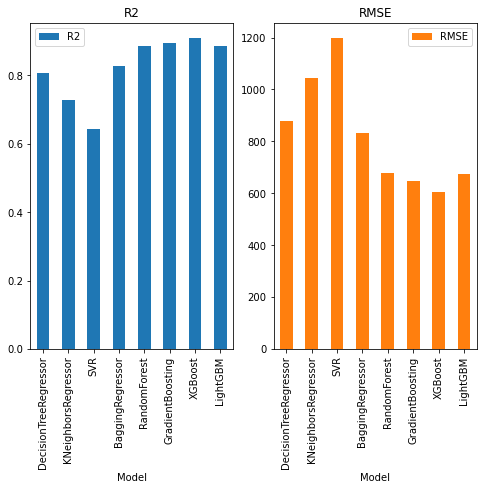

In [116]:
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

models = {
    "DecisionTreeRegressor" : dtg,
    "KNeighborsRegressor" :knn,
    "SVR" : svr,
    "BaggingRegressor" : bg,
    "RandomForest": rf,
    "GradientBoosting": gbg,
    "XGBoost": xgb_model,
    "LightGBM": lgbm
}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)  # no squared parameter
    rmse = np.sqrt(mse)
    results.append([name, r2, rmse])

results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE'])
print(results_df)


# Plot
results_df.set_index('Model')[['R2','RMSE']].plot(kind='bar', figsize=(8,6), subplots=True, layout=(1,2))
plt.show()


In [117]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Using your best tuned XGB
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=26
)
xgb_model.fit(x_train, y_train)

print(" Train R²:", xgb_model.score(x_train, y_train)*100)
print(" Test R²:", xgb_model.score(x_test, y_test)*100)


 Train R²: 99.94113445281982
 Test R²: 90.88290929794312


### Feature importance

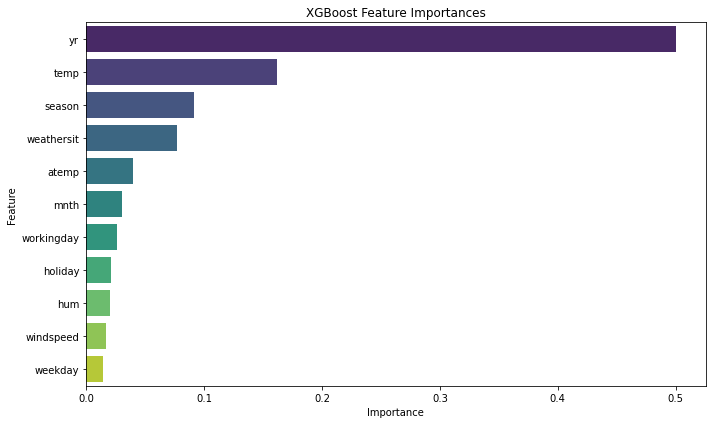

In [118]:
# Get feature importances
importances = xgb_model.feature_importances_
features = x_train.columns

# Create a DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

### Actual vs Predicted Bike Count (XGBoost)

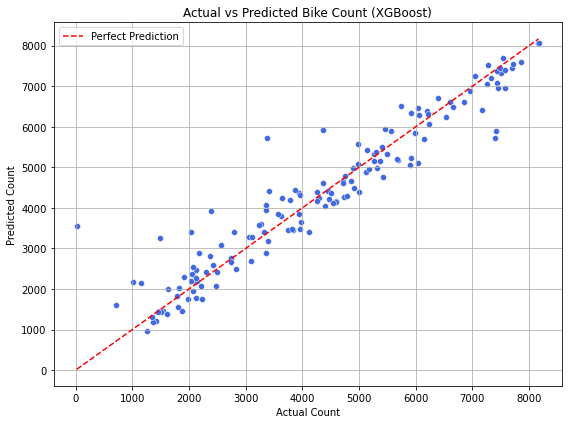

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict with your trained XGBoost model
y_pred = xgb_model.predict(x_test)

# Plot setup
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', edgecolor='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted Bike Count (XGBoost)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Residuals Distribution using bargraph (xgboost)

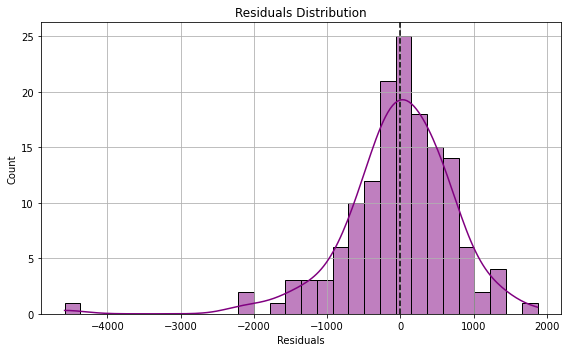

In [120]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()


# Residuals of scatterplot (xgboost)

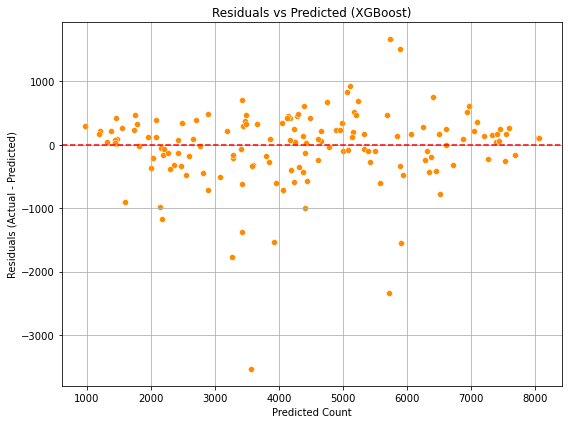

In [121]:
# Residuals
y_pred = xgb_model.predict(x_test)
residuals = y_test - y_pred

# Plot residuals vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, color='darkorange', edgecolor='white')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Count")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()

## learning_curve XGBosst

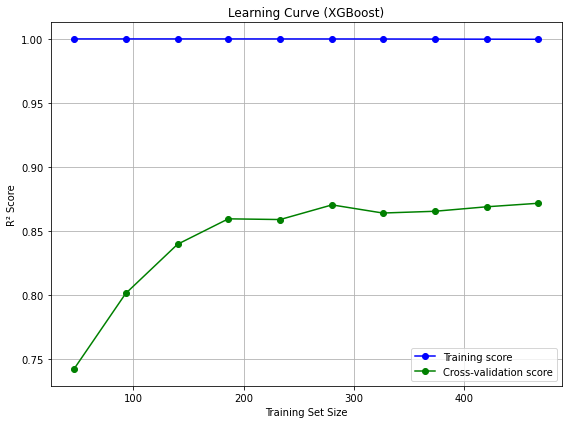

In [122]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    xgb_model, x_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation score')
plt.title("Learning Curve (XGBoost)")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


# save model

In [123]:
import joblib
import xgboost as xgb
import os

#  Path to save model
MODEL_PATH = r"C:\Users\santh\OneDrive\Desktop\stramlitfinal"
MODEL_FILE = "xgb_bike_rentals.pkl"
FULL_PATH = os.path.join(MODEL_PATH, MODEL_FILE)

#  Save model
joblib.dump(model, FULL_PATH)
print(f" Model saved at {FULL_PATH}")

#  Load model safely
try:
    loaded_model = joblib.load(FULL_PATH)
    print(" Model loaded successfully")
except Exception as e:
    print(f" Failed to load model: {e}")


 Model saved at C:\Users\santh\OneDrive\Desktop\stramlitfinal\xgb_bike_rentals.pkl
 Model loaded successfully


## prediction

In [124]:
final_model = xgb_model   #assigning model


In [125]:
#  Manual input in correct order
manual_input = pd.DataFrame([[
    1,     # season
    0,     # yr
    1,     # mnth
    0,     # holiday
    6,     # weekday
    0,     # workingday
    2,     # weathersit
    0.344167,   # temp
    0.363625,  # atemp
    0.805833,   # hum
    0.160446    # windspeed
]], columns=x.columns)

#  Predict
predicted_count = final_model.predict(manual_input)
print(" Predicted bike count:", round(predicted_count[0]))


 Predicted bike count: 1004


In [126]:
# To check which model i am using for prediction

print(type(final_model))


<class 'xgboost.sklearn.XGBRegressor'>


In [127]:
# Jupyter
final_model = xgb_model  # Should match the saved one

# Streamlit
joblib.load("xgb_bike_rentals.pkl")


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=26, ...)

In [128]:
# #new(actual vs predict) 
# 1	0	1	0	6	0	2	0.344167	0.363625	0.805833	0.160446	   actual output=985         predecited output=1004
# 1	0	2	0	5	1	2	0.364348	0.350461	0.712174	0.346539	   actual output=1461,       predecited output=1438
# 1	0	2	0	6	0	1	0.2825	0.282192	0.537917	0.186571	       actual output=1969        predecited output=1957
# 1	0	2	0	0	0	1	0.343478	0.351109	0.68	0.125248	       actual output=2402        predecited output=2377
# 1	0	1	0	2	1	1	0.2	0.212122	0.590435	0.160296=              actual output=1558        predecited output=1555
# 1	0	2	0	0	0	1	0.285217	0.27733	0.407826	0.223235		   actual output=1812        predecited output=1843
# 1	0	2	1	1	0	2	0.303333	0.284075	0.605	0.307846		   actual output=1107        predecited output=1138
# 1	0	2	0	2	1	1	0.182222	0.186033	0.577778	0.195683	   actual output=1450        predecited output=1450
# 1	0	2	0	3	1	1	0.221739	0.245717	0.423043	0.094113	   actual output=1917        predecited output=1907
# 1	0	2	0	4	1	2	0.295652	0.289191	0.697391	0.250496	   actual output=1807        predecited output=1546


In [129]:
#previous
# 1	0	2	0	5	1	2	0.364348	0.350461	0.712174	0.346539	     actual output=1461,       predecited output =1414.29
# 1	0	2	0	6	0	1	0.2825	0.282192	0.537917	0.186571	         actual output=1969        predecited output= 1923.60
# 1	0	2	0	0	0	1	0.343478	0.351109	0.68	0.125248	         actual output=2402        predecited output= 2007.50


In [130]:

# Sample    Actual    Predicted         Error
#  1        1461       1438             -23
#  2        1969       1957             -12
#  3        2402       2377             -25
#  4        1558       1555             -3
#  5        1812       1843             +31
#  6        1107       1138             +31
#  7        1450       1450              0
#  8        1917       1907             -10
#  9        1807       1546             -261

## file loaction

In [131]:
pwd


'C:\\Users\\santh'

# Conclusion 

After exploring several models, the XGBoost model demonstrated the strongest performance for this bike rental prediction task. Its ability to capture complex non-linear relationships in the data allowed it to achieve a high degree of accuracy.

The final model's metrics are as follows:

⦁ Training Accuracy: 99.94
⦁ Testing Accuracy: 90.88
⦁ R2 Score: 90.88
⦁ RMSE Score: 604.64


The high training accuracy, coupled with the slightly lower but still strong testing accuracy, suggests a robust model that generalizes well to unseen data. The R2 score of 0.9088 indicates that the model can explain over 90 of the variance in the bike rental demand, which is an excellent result for a real-world prediction problem. The RMSE score gives us an idea of the average error, with our model being, on average, about 605 rentals off from the actual daily count. This is a very strong and reliable model for our business goals.